In [ ]:
import zarr
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 対象ディレクトリの検索
base_path = Path("/Volumes/data/Sasaki/MTsingleBeads")

def plot_RDF(base_path, ax=None, diameter = 0.63, color='C0', marker = "^"):
    dirs = glob.glob(base_path)

    rdf_list = []
    for d in dirs:
        zarr_path = os.path.join(d, "RDF.zarr")
        # RDF.zarr が存在するものだけをロード
        if os.path.exists(zarr_path):
            print(f"Loading: {zarr_path}")
            rdf = zarr.open_array(zarr_path, mode='r')[:]
            rdf_list.append(rdf)

    if len(rdf_list) > 0:
        # 全てのRDF配列を縦に結合 (Particle数 × 距離)
        all_rdfs = np.concatenate(rdf_list, axis=0)
        
        # x軸（距離）の計算
        max_r = all_rdfs.shape[1]
        scale = 0.11 # um/px (RDF.pyの設定に合わせる)
        r = np.arange(max_r) * scale
        
        # 平均と標準誤差を計算
        rdf_mean = np.nanmean(all_rdfs, axis=0)
        rdf_sem = np.nanstd(all_rdfs, axis=0) / np.sqrt(len(all_rdfs))
        potential = -np.log(rdf_mean) 
        
        # グラフの描画
        if ax is None:
            fig, ax = plt.subplots()
        ax.plot(r, rdf_mean, label=f'{diameter} μm', color=color, marker = marker)
        ax.fill_between(r, rdf_mean - rdf_sem, rdf_mean + rdf_sem, color='C0', alpha=0.3)
        
        if ax is None:
            # バルク平均（g(r)=1）の基準線
            ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
            
            ax.set_xlabel('Distance [μm]')
            ax.set_ylabel('RDF $g(r)$')
            ax.set_title('Radial Distribution Function')
            ax.legend()

            plt.show()
            
    else:
        print("有効な RDF.zarr が見つかりませんでした。")

    
def plot_potenrial(base_path, ax=None, diameter = 0.63, color='C0', marker = "^"):
    dirs = glob.glob(base_path)

    rdf_list = []
    for d in dirs:
        zarr_path = os.path.join(d, "RDF.zarr")
        # RDF.zarr が存在するものだけをロード
        if os.path.exists(zarr_path):
            print(f"Loading: {zarr_path}")
            rdf = zarr.open_array(zarr_path, mode='r')[:]
            rdf_list.append(rdf)

    if len(rdf_list) > 0:
        # 全てのRDF配列を縦に結合 (Particle数 × 距離)
        all_rdfs = np.concatenate(rdf_list, axis=0)
        
        # x軸（距離）の計算
        max_r = all_rdfs.shape[1]
        scale = 0.11 # um/px (RDF.pyの設定に合わせる)
        r = np.arange(max_r) * scale
        
        # 平均と標準誤差を計算
        rdf_mean = np.nanmean(all_rdfs, axis=0)
        rdf_sem = np.nanstd(all_rdfs, axis=0) / np.sqrt(len(all_rdfs))
        
        # グラフの描画
        if ax is None:
            fig, ax = plt.subplots()
        ax.plot(r, rdf_mean, label=f'{diameter} μm', color=color, marker = marker)
        ax.fill_between(r, rdf_mean - rdf_sem, rdf_mean + rdf_sem, color='C0', alpha=0.3)
        
        if ax is None:
            # バルク平均（g(r)=1）の基準線
            ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
            
            ax.set_xlabel('Distance [μm]')
            ax.set_ylabel('RDF $g(r)$')
            ax.set_title('Radial Distribution Function')
            ax.legend()

            plt.show()
            
    else:
        print("有効な RDF.zarr が見つかりませんでした。")


Loading: /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um001/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um002/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um003/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um001_crop/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um002/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um003/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um_crop/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um001/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um002/RDF.zarr
Loading: /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um003/RDF.

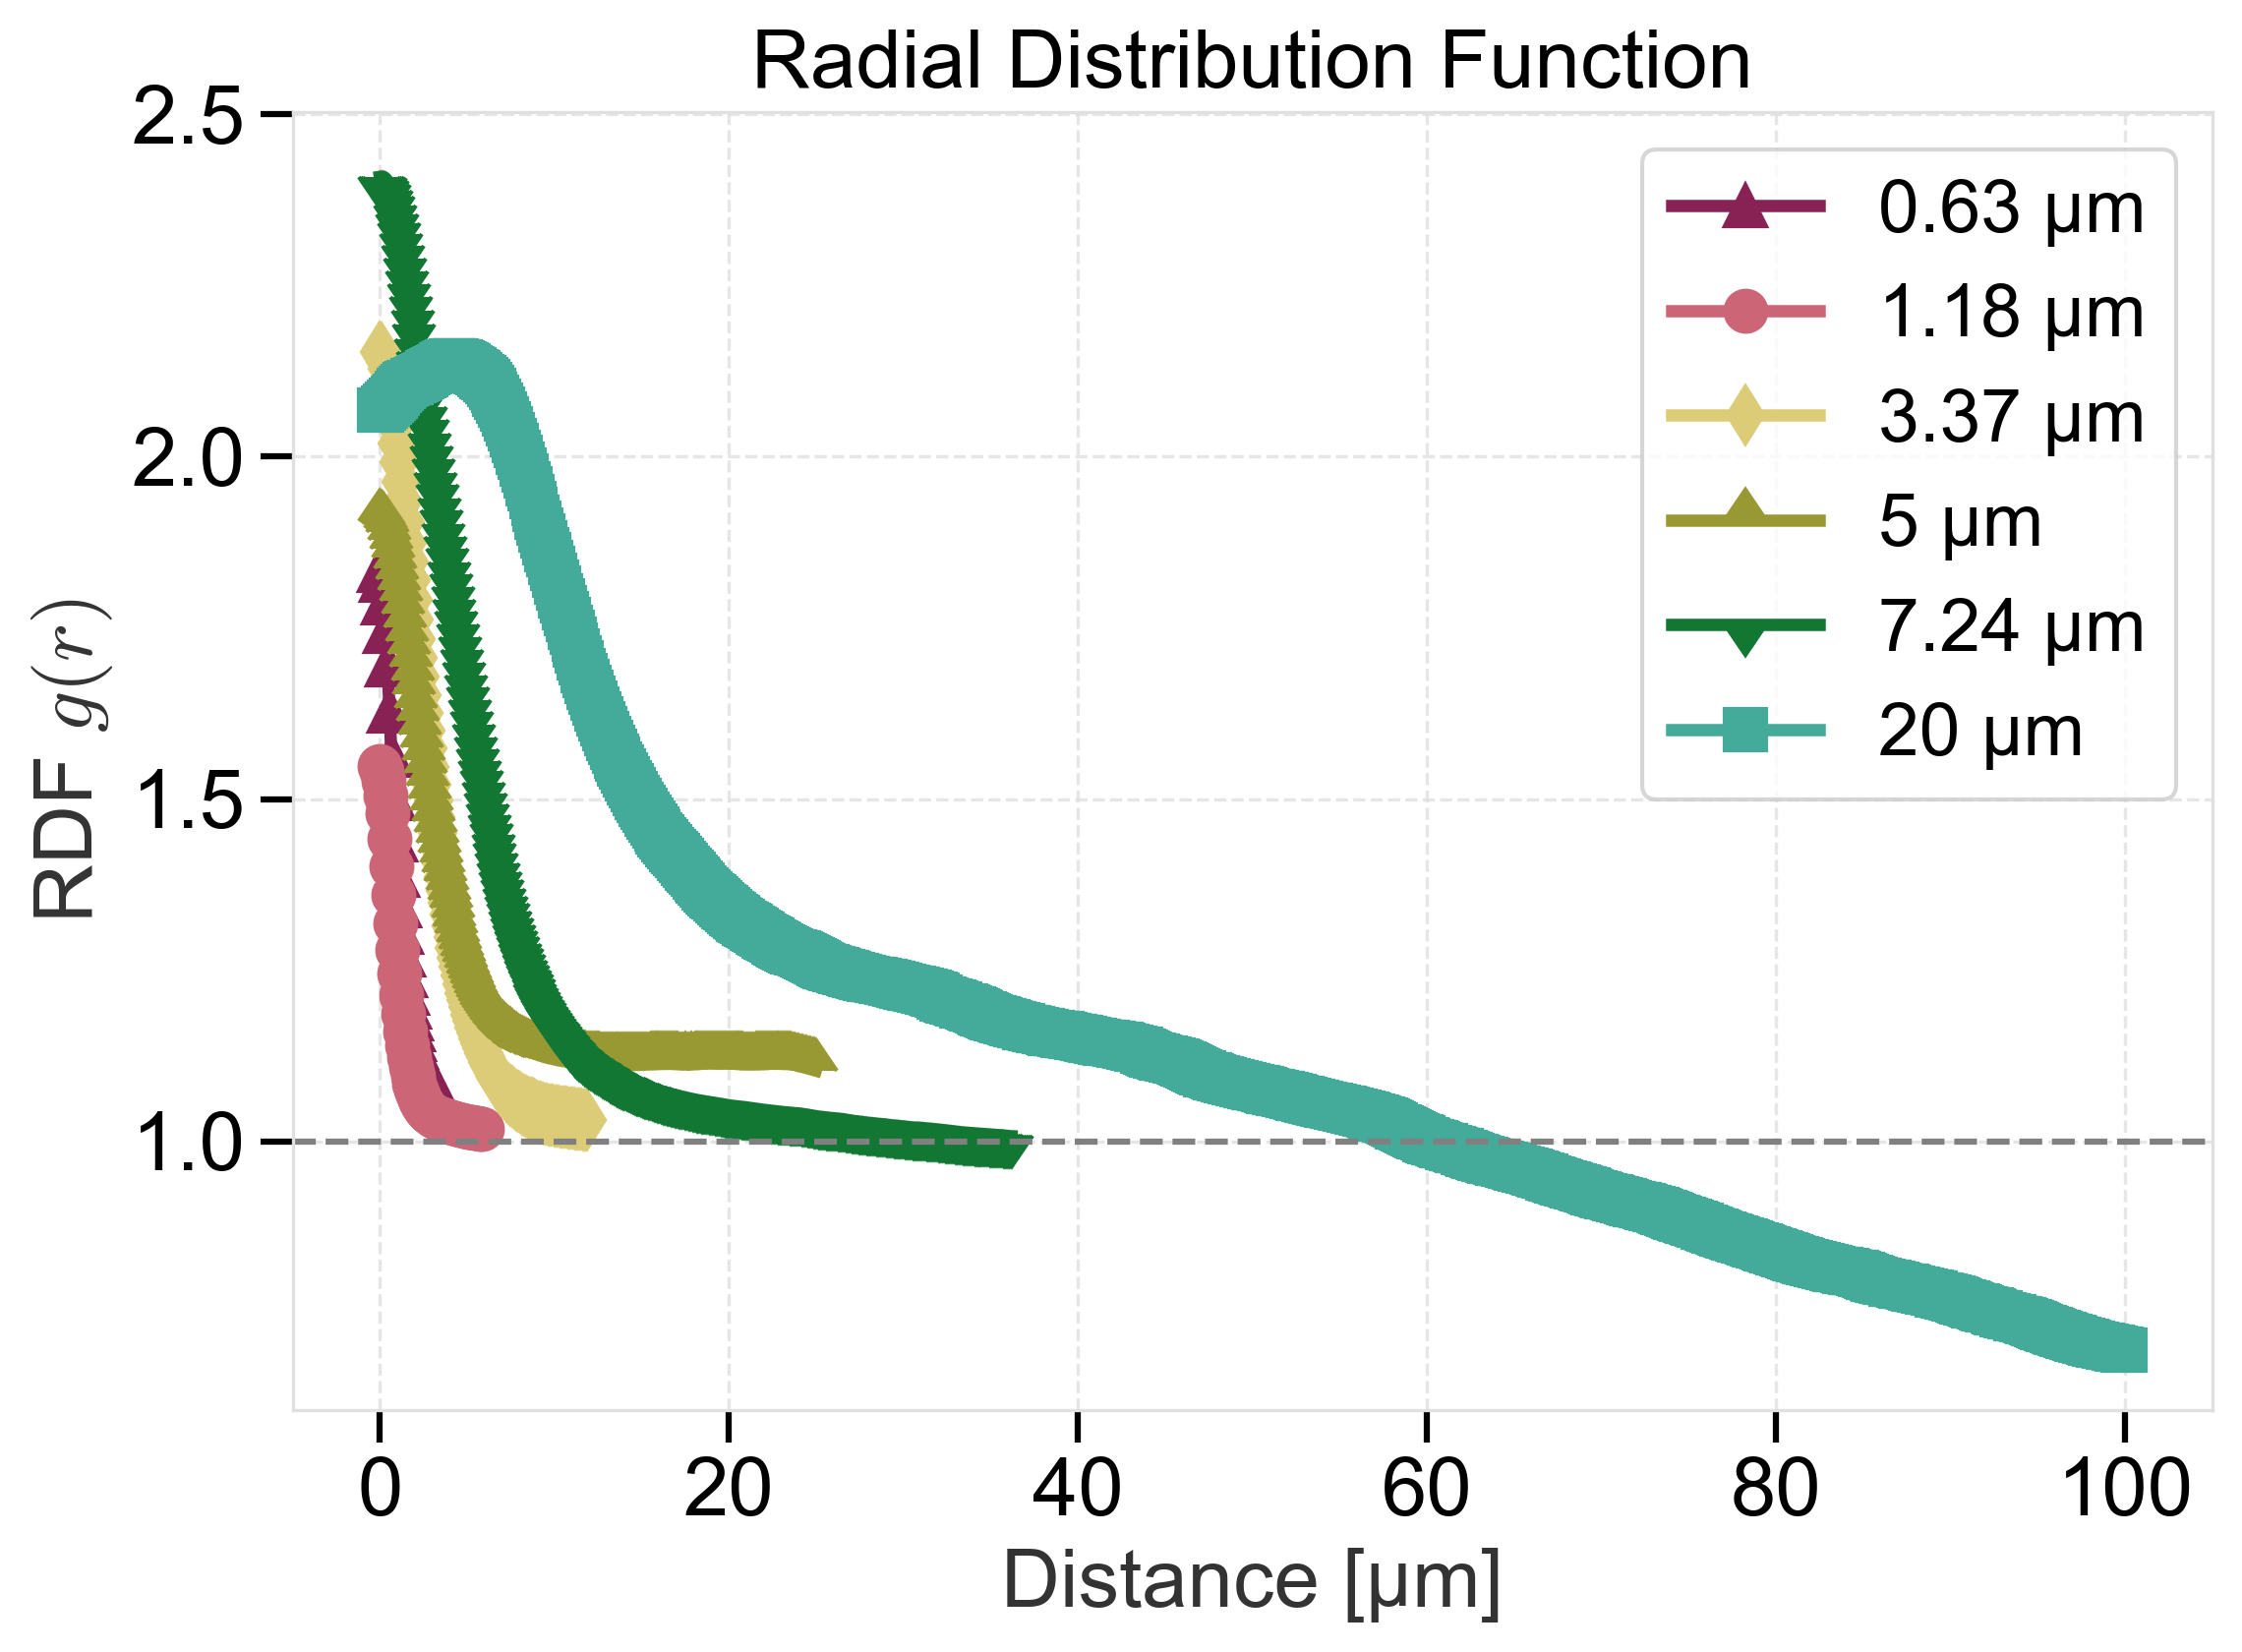

In [ ]:
fig, ax  = plt.subplots()

plot_RDF(str(base_path / "beads06um/*/*"), ax=ax, diameter = 0.63, color='C0', marker = "^")
plot_RDF(str(base_path / "beads1um/*/*"), ax=ax, diameter = 1.18, color='C1', marker = "o")
plot_RDF(str(base_path / "beads3um/*/*"), ax=ax, diameter = 3.37, color='C2', marker = "d")
plot_RDF(str(base_path / "beads5um/*/*"), ax=ax, diameter = 5, color='C3', marker = 10)
plot_RDF(str(base_path / "beads7um/*/*"), ax=ax, diameter = 7.24, color='C4', marker = 11)
plot_RDF(str(base_path / "beads20um/*/*"), ax=ax, diameter = 20, color='C5', marker = 's')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
            
ax.set_xlabel('Distance [μm]')
ax.set_ylabel('RDF $g(r)$')
ax.set_title('Radial Distribution Function')
ax.legend()